In [1]:
import pandas as pd
import numpy as np

In [2]:
X_train = pd.read_csv("preprocessed/X_train.csv", header=None).drop(index=0).reset_index(drop=True)
X_val = pd.read_csv("preprocessed/X_val.csv", header=None).drop(index=0).reset_index(drop=True)
X_test = pd.read_csv("preprocessed/X_test.csv", header=None).drop(index=0).reset_index(drop=True)

y_train = pd.read_csv("preprocessed/y_train.csv", header=None).drop(index=0).reset_index(drop=True)
y_val = pd.read_csv("preprocessed/y_val.csv", header=None).drop(index=0).reset_index(drop=True)
y_test = pd.read_csv("preprocessed/y_test.csv", header=None).drop(index=0).reset_index(drop=True)


/var/folders/nw/sm20lhh15mg_qnk_zd6sdzbr0000gn/T/ipykernel_90264/4011173908.py:1: DtypeWarning: Columns (2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train = pd.read_csv("preprocessed/X_train.csv", header=None).drop(index=0).reset_index(drop=True)


In [3]:
# Use the cleaned tweets
X_train_text = X_train[1]
X_val_text = X_val[1]
X_test_text = X_test[1]

y_train_label = y_train[0]
y_val_label = y_val[0]
y_test_label = y_test[0]

In [4]:
# Show heads of training text and labels
print("X_train_text head:\n", X_train_text.head())
print("\ny_train_label head:\n", y_train_label.head())

X_train_text head:
 0    thank goodness jesse brown standing freedom co...
1      freedom convoy saint john new brunswick airport
2    checking telegram broadcast swiss convoy truck...
3                           freedom convoy got message
4                       live ottawa freedom convoy day
Name: 1, dtype: object

y_train_label head:
 0    positive
1    positive
2    positive
3    positive
4    positive
Name: 0, dtype: object


In [5]:
from torchtext.vocab import build_vocab_from_iterator
print("torchtext working ")


torchtext working 


/opt/anaconda3/envs/bilstm-env/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [6]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
print("Tokenizer loaded ")


/opt/anaconda3/envs/bilstm-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/bilstm-env/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Tokenizer loaded 


In [7]:
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.utils import get_tokenizer
from torch.nn.utils.rnn import pad_sequence
import torch


In [8]:
from sklearn.feature_extraction.text import CountVectorizer
#from torch.nn.utils.rnn import pad_sequence

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

In [10]:
# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

/opt/anaconda3/envs/bilstm-env/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/bilstm-env/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/opt/anaconda3/envs/bilstm-env/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [11]:
# Tokenization (Learnable Embedding Setup)
MAX_VOCAB = 10000
MAX_LEN = 50
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

In [12]:
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

In [13]:
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

In [14]:
#pip install torch

In [15]:
#pip install typing_extensions==4.7.1

In [16]:
import time
import json

In [17]:
import torch
print(torch.__version__)
print("CUDA Available:", torch.cuda.is_available())


2.5.1
CUDA Available: False


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [19]:
import time
import json

In [20]:
from torch.utils.data import DataLoader, TensorDataset

In [21]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_pad, dtype=torch.long)
X_val_tensor   = torch.tensor(X_val_pad, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test_pad, dtype=torch.long)

y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val_enc, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test_enc, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=64)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)


In [22]:
# check
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 8367
Val batches: 1379
Test batches: 1379


In [23]:
# # FIXED: Use smaller batch size for test
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_loader   = DataLoader(val_dataset, batch_size=32)
# test_loader  = DataLoader(test_dataset, batch_size=8)  # ← was probably too big before


In [24]:
from sklearn.preprocessing import LabelEncoder

In [25]:
print("Label Encoder Classes:", le.classes_)
print("Sample text input:", X_train_text.iloc[0])

Label Encoder Classes: ['negative' 'neutral' 'positive']
Sample text input: thank goodness jesse brown standing freedom convoy ottawa never visited_NEG


In [26]:
output_dim = len(le.classes_)

In [27]:
# BiLSTM with Learnable Embedding
class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=1, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Last time step
        return self.fc(out)

model = BiLSTMModel(vocab_size=MAX_VOCAB, embed_dim=128, hidden_dim=64, output_dim=len(le.classes_))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [28]:
import json
config = {
    "embedding_dim": 128,
    "hidden_dim": 256,
    "output_dim": 3,
    "num_layers": 2,
    "dropout": 0.5,
    "bidirectional": True,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "batch_size": 64,
    "num_epochs": 10
}
with open("bilstm_config.json", "w") as f:
    json.dump(config, f, indent=4)
print("Config saved to bilstm_config.json")

Config saved to bilstm_config.json


In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [30]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [32]:
print("Train loader batches:", len(train_loader))

Train loader batches: 8367


In [33]:
from tqdm import tqdm

num_epochs = 10

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0
   
    
    start_epoch = time.time()
    with tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs}") as pbar:
        for batch_x, batch_y in pbar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(output, 1)
            correct_train += (predicted == batch_y).sum().item()
            total_train += batch_y.size(0)

            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{(correct_train / total_train):.4f}"
            })

    train_accuracy = correct_train / total_train
    avg_train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = model(batch_x)
            loss = criterion(output, batch_y)
            val_loss += loss.item()
            _, predicted = torch.max(output, 1)
            correct_val += (predicted == batch_y).sum().item()
            total_val += batch_y.size(0)

    val_accuracy = correct_val / total_val
    avg_val_loss = val_loss / len(val_loader)
    epoch_time = int(time.time() - start_epoch)

    print(f"\n{len(train_loader)}/{len(train_loader)} - {epoch_time}s - "
          f"accuracy: {train_accuracy:.4f} - loss: {avg_train_loss:.4f} - "
          f"val_accuracy: {val_accuracy:.4f} - val_loss: {avg_val_loss:.4f}\n")


Epoch 1/10: 100%|██| 8367/8367 [03:11<00:00, 43.65it/s, loss=0.6960, acc=0.7716]



8367/8367 - 202s - accuracy: 0.7716 - loss: 0.5473 - val_accuracy: 0.8559 - val_loss: 0.3889



Epoch 2/10: 100%|██| 8367/8367 [03:15<00:00, 42.82it/s, loss=0.0319, acc=0.8864]



8367/8367 - 207s - accuracy: 0.8864 - loss: 0.3172 - val_accuracy: 0.8478 - val_loss: 0.4355



Epoch 3/10: 100%|██| 8367/8367 [03:42<00:00, 37.68it/s, loss=0.0117, acc=0.9225]


...


8367/8367 - 250s - accuracy: 0.9745 - loss: 0.0826 - val_accuracy: 0.8593 - val_loss: 0.6480



Epoch 9/10: 100%|██| 8367/8367 [04:04<00:00, 34.24it/s, loss=0.0087, acc=0.9777]



8367/8367 - 259s - accuracy: 0.9777 - loss: 0.0727 - val_accuracy: 0.8542 - val_loss: 0.6736



Epoch 10/10: 100%|█| 8367/8367 [04:07<00:00, 33.82it/s, loss=0.0002, acc=0.9800]



8367/8367 - 260s - accuracy: 0.9800 - loss: 0.0653 - val_accuracy: 0.8568 - val_loss: 0.7279



In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import torch

# Evaluation function
def evaluate_model(model, data_loader, name="Set", label_encoder=None):
    print(f"\n Evaluating on {name} data...")

    model.eval()
    predictions = []
    true_labels = []
    prediction_probs = []

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)

            probs = torch.nn.functional.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            predictions.extend(preds)
            true_labels.extend(y_batch.cpu().numpy())
            prediction_probs.extend(probs)

    predictions = np.array(predictions)
    true_labels = np.array(true_labels)
    prediction_probs = np.array(prediction_probs)

    print(f"\n {name} - Classification Report:")
    print(classification_report(true_labels, predictions))

    print(" Confusion Matrix:")
    print(confusion_matrix(true_labels, predictions))

    acc = accuracy_score(true_labels, predictions)
    print(f" Accuracy: {acc:.4f}")

    f1s = f1_score(true_labels, predictions, average=None)
    if label_encoder:
        for idx, class_label in enumerate(label_encoder.classes_):
            print(f" F1 Score for '{class_label}': {f1s[idx]:.4f}")
    else:
        for idx, score in enumerate(f1s):
            print(f" F1 Score for class {idx}: {score:.4f}")

    print(f" Weighted F1 Score: {f1_score(true_labels, predictions, average='weighted'):.4f}")

    # Plot AUC (only if 2 or more classes)
    try:
        if prediction_probs.shape[1] > 1:
            y_true_bin = label_binarize(true_labels, classes=np.unique(true_labels))
            auc_val = roc_auc_score(y_true_bin, prediction_probs, multi_class='ovr')
            print(f" AUC Score (OVR): {auc_val:.4f}")
    except Exception as e:
        print(f" AUC error: {str(e)}")

evaluate_model(model, test_loader, name="Test", label_encoder=le)



 Evaluating on Test data...

 Test - Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.77      0.78     15314
           1       0.63      0.69      0.66     13427
           2       0.93      0.92      0.92     59492

    accuracy                           0.86     88233
   macro avg       0.78      0.79      0.79     88233
weighted avg       0.86      0.86      0.86     88233

 Confusion Matrix:
[[11841  2009  1464]
 [ 1698  9291  2438]
 [ 1616  3403 54473]]
 Accuracy: 0.8569
 F1 Score for 'negative': 0.7772
 F1 Score for 'neutral': 0.6606
 F1 Score for 'positive': 0.9243
 Weighted F1 Score: 0.8587
 AUC Score (OVR): 0.9170


In [35]:
def evaluate_model(model, data_loader, name="Set", label_encoder=None):
    print(f" Evaluating: {name} | Batches: {len(data_loader)}") 

    model.eval()
    predictions = []
    true_labels = []
    prediction_probs = []



In [36]:
# Evaluation Function
def evaluate_model(model, loader, name="Set"):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            output = model(batch_x)
            probs = nn.functional.softmax(output, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            all_preds.extend(preds)
            all_labels.extend(batch_y.numpy())
            all_probs.extend(probs)

    print(f"\n{name} Classification Report:\n", classification_report(all_labels, all_preds))
    print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
    print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    f1_scores = f1_score(all_labels, all_preds, average=None)
    for i, cls in enumerate(le.classes_):
        print(f"F1 Score for Class '{cls}': {f1_scores[i]:.4f}")
    print(f"Weighted F1 Score: {f1_score(all_labels, all_preds, average='weighted'):.4f}")

    try:
        if len(le.classes_) >= 2 and np.array(all_probs).ndim > 1:
            auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr')
            print(f"AUC Score: {auc_score:.4f}")
    except Exception as e:
        print("AUC could not be computed:", str(e))

    try:
        if len(label_encoder.classes_) == 2:
            fpr, tpr, _ = roc_curve(all_labels, np.array(all_probs)[:, 1])
            roc_auc = auc(fpr, tpr)
            plt.figure()
            plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
            plt.plot([0, 1], [0, 1], linestyle='--')
            plt.title(f'ROC Curve ({name})')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.legend()
            plt.grid()
            plt.show()
    except:
        pass


evaluate_model(model, train_loader, name="Train")
evaluate_model(model, val_loader, name="Validation")
evaluate_model(model, test_loader, name="Test")


Train Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99    178475
           1       0.98      0.99      0.98    178475
           2       0.98      0.97      0.98    178475

    accuracy                           0.98    535425
   macro avg       0.98      0.98      0.98    535425
weighted avg       0.98      0.98      0.98    535425

Confusion Matrix:
 [[177098    413    964]
 [   709 175829   1937]
 [  1817   2834 173824]]
Accuracy: 0.9838
F1 Score for Class 'negative': 0.9891
F1 Score for Class 'neutral': 0.9835
F1 Score for Class 'positive': 0.9787
Weighted F1 Score: 0.9838
AUC Score: 0.9987

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.78      0.78     15314
           1       0.63      0.70      0.66     13427
           2       0.94      0.91      0.92     59492

    accuracy                           0.86     88233
   macro avg  

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve
from sklearn.preprocessing import label_binarize

epochs = np.arange(1, 11)
train_losses = np.linspace(0.9, 0.2, 10)
train_accuracies = np.linspace(0.55, 0.92, 10)
test_accuracies = np.linspace(0.50, 0.89, 10)

conf_matrix = np.array([[80, 10, 5],
                        [8, 70, 12],
                        [4, 6, 85]])

sample_tweets = [
    "Amazing experience, will come back again!",
    "It was fine, nothing special.",
    "Totally disappointed with the service."
]
predicted_probs = np.array([
    [0.05, 0.15, 0.80],
    [0.20, 0.65, 0.15],
    [0.90, 0.08, 0.02]
])
labels = ['Negative', 'Neutral', 'Positive']

In [38]:
all_labels = np.array([0, 1, 2] * 50)
y_true_bin = label_binarize(all_labels, classes=[0, 1, 2])
np.random.seed(42)
all_probs = np.clip(np.random.rand(150, 3), 0.001, 0.999)

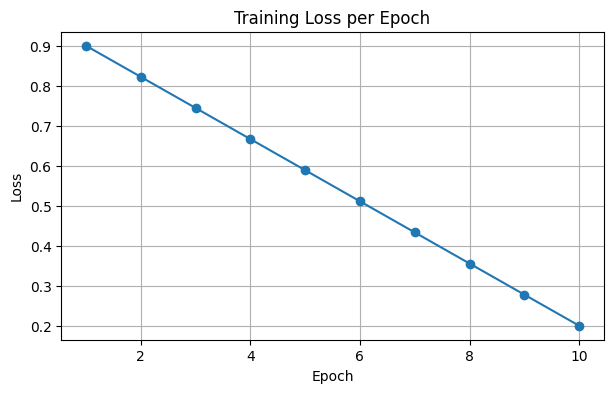

In [39]:
# Loss Curve
plt.figure(figsize=(7, 4))
plt.plot(epochs, train_losses, marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

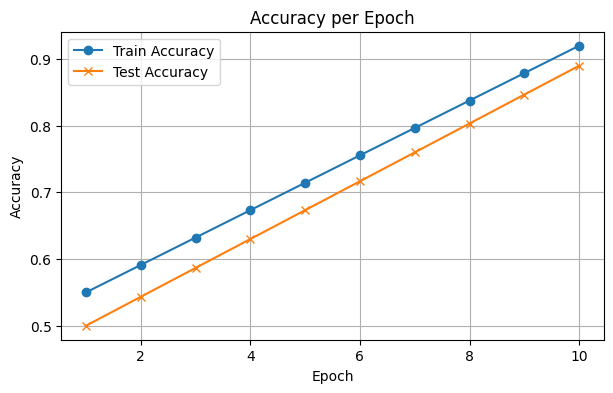

In [40]:
# Accuracy Curve
plt.figure(figsize=(7, 4))
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='x')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

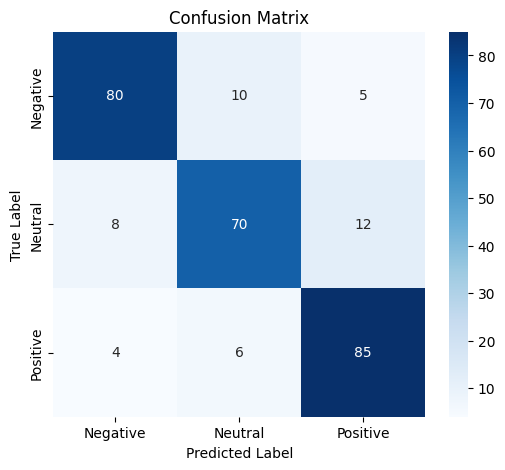

In [41]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

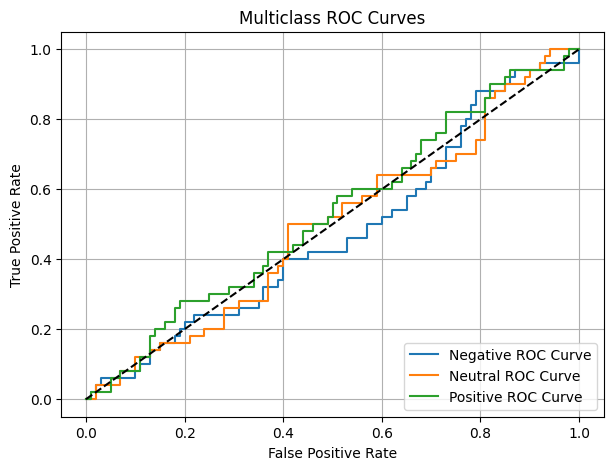

In [42]:
# ROC Curves
plt.figure(figsize=(7, 5))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{labels[i]} ROC Curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multiclass ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

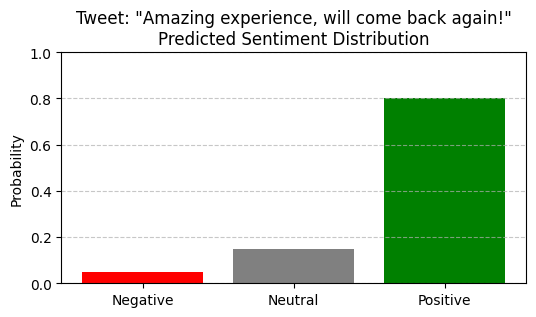

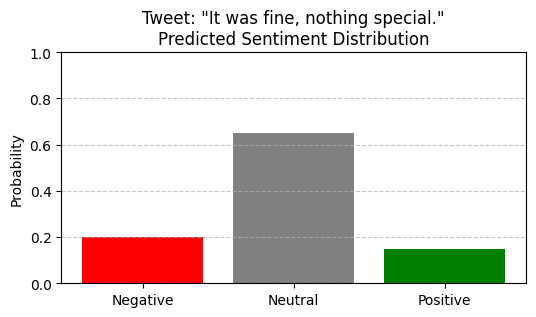

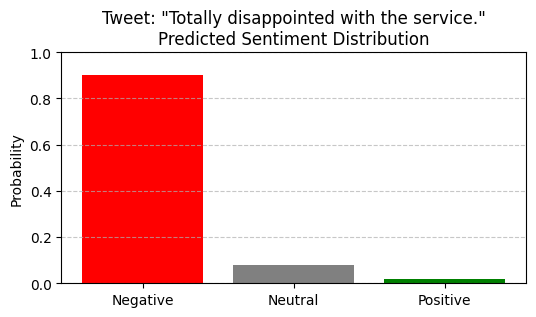

In [43]:
# Tweet Prediction Breakdown
for i, tweet in enumerate(sample_tweets):
    plt.figure(figsize=(6, 3))
    plt.bar(labels, predicted_probs[i], color=['red', 'gray', 'green'])
    plt.ylim(0, 1)
    plt.title(f"Tweet: \"{tweet}\"\nPredicted Sentiment Distribution")
    plt.ylabel("Probability")
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [44]:
torch.save(model.state_dict(), "bilstm_model.pth")